# House Price Prediction with Machine Learning

This project investigates the prediction of median house values using the California Housing dataset. The objective is to compare multiple regression models, analyse prediction errors, investigate overfitting and generalisation, and identify the features most influential to the strongest-performing model.

## 1. Import Libraries

## 2. Load and Prepare the Dataset

The California Housing dataset contains eight numerical features describing census block groups. The target variable is median house value, expressed in units of $100,000.

In [40]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

### Load the California Housing Dataset

In [41]:
housing = fetch_california_housing()

### Explore the Dataset

In [42]:
type(housing)
housing.feature_names
housing.DESCR

'.. _california_housing_dataset:\n\nCalifornia Housing dataset\n--------------------------\n\n**Data Set Characteristics:**\n\n:Number of Instances: 20640\n\n:Number of Attributes: 8 numeric, predictive attributes and the target\n\n:Attribute Information:\n    - MedInc        median income in block group\n    - HouseAge      median house age in block group\n    - AveRooms      average number of rooms per household\n    - AveBedrms     average number of bedrooms per household\n    - Population    block group population\n    - AveOccup      average number of household members\n    - Latitude      block group latitude\n    - Longitude     block group longitude\n\n:Missing Attribute Values: None\n\nThis dataset was obtained from the StatLib repository.\nhttps://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html\n\nThe target variable is the median house value for California districts,\nexpressed in hundreds of thousands of dollars ($100,000).\n\nThis dataset was derived from the 1990 U.S

### Create a Pandas DataFrame

In [43]:
data = housing.data
column_names = housing.feature_names

df = pd.DataFrame(data, columns=column_names)

df['target'] = housing.target
display(df.head())

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## 3. Prepare the Data for Machine Learning

The features (`X`) contain the predictor variables, while the target (`y`) contains the median house value. The dataset is then split into training and testing sets to evaluate model performance on unseen data.

In [44]:
y = df['target']
X = df[['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population',
       'AveOccup', 'Latitude', 'Longitude']]

### Train-Test Split

In [57]:
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size = 0.2,
                                                    random_state = 42
                                                    )

## 4. Linear Regression

In [46]:
model_1 = LinearRegression()

model_1.fit(X_train, y_train)

predictions = model_1.predict(X_test)

## 5. Evaluate the Linear Regression Model

In [47]:
mae = mean_absolute_error(y_test, predictions) #compare the true values against predictions
r2 = r2_score(y_test, predictions)
print('r2 for linear regression score is:',r2)
print('The predictions are', mae, 'units away from the real values')


r2 for linear regression score is: 0.5757877060324508
The predictions are 0.5332001304956553 units away from the real values


## 6. Residual Analysis

In [48]:
residuals = (y_test - predictions)
residuals = residuals.abs()
residuals = residuals.sort_values(ascending=False)

worst_rows = df.loc[[1979, 6688, 10574, 12389, 19542]]
# display(worst_rows)

display('worst row:', df.loc[[6876]])

#The model may perform especially poorly for unusually low-population block groups.
#We cannot conclude this from 5 rows, we must inspect if
#low population districs have larger prediction errors on average

population_errors = pd.concat([X_test['Population'], residuals], axis=1)
population_errors.columns = ['Population', 'absolute error']
display('population vs absolute error:', population_errors.head())

'worst row:'

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
6876,2.4931,36.0,3.668639,1.032544,1383.0,4.091716,34.07,-118.1,1.703


'population vs absolute error:'

,Population,absolute error
20046,1392.0,0.242123
3024,1565.0,1.306017
15663,1310.0,2.290351
20484,1705.0,0.652926
9814,1063.0,0.175343


## Does the Linear Regression model perform worse for low-population block groups?

In [49]:
population_errors_less_600 = population_errors[population_errors['Population'] < 600]
population_errors_more_600 = population_errors[population_errors['Population'] >= 600]

mean_error_less = population_errors_less_600['absolute error'].mean()
mean_error_more = population_errors_more_600['absolute error'].mean()

print('absolute error - population less 600:', mean_error_less)
print('absolute error - population more 600:', mean_error_more)

#hypothesis is correct, model performs worse for low population

absolute error - population less 600: 0.6918409911160377
absolute error - population more 600: 0.507474585530188


In [50]:
#Check imbalance of sample sizes

print('lower:',len(population_errors_less_600))
print('higher:',len(population_errors_more_600))
#576 vs 3552

lower: 576
higher: 3552


In [51]:
less_600_median = population_errors_less_600['absolute error'].median()
more_600_median = population_errors_more_600['absolute error'].median()

print('median error - population less 600:', less_600_median)
print('median error - population more 600:', more_600_median)

median error - population less 600: 0.5124776611817591
median error - population more 600: 0.39763734957587593


The Linear Regression model performs worse on low-population block groups. The higher error persists across both mean and median absolute error, suggesting the effect is not solely driven by a few extreme outliers. It’s not just one or two insane predictions making low-population blocks look bad. A typical low-population block also has a larger prediction error than a typical higher-population block.

## 7. Decision Tree Regression

In [52]:
model_2 = DecisionTreeRegressor()
model_2.fit(X_train, y_train)
predictions_2 = model_2.predict(X_test)
mae_2 = mean_absolute_error(y_test, predictions_2)
print('The predictions are', mae_2, 'units away from the real values')
r2_model_2 = r2_score(y_test, predictions_2)
print('The capture of variation was:', r2_model_2)


train_predictions_2 = model_2.predict(X_train)
mae_train_2 = mean_absolute_error(y_train, train_predictions_2)
print('The predictions are', mae_train_2, 'units away from the real values')
r2_train_2 = r2_score(y_train, train_predictions_2)
print('The capture of variation was:', r2_train_2)

The predictions are 0.4542562039728682 units away from the real values
The capture of variation was: 0.6219458927108553
The predictions are 4.1203044421650673e-17 units away from the real values
The capture of variation was: 1.0


The Decision Tree improves test performance over Linear Regression but severely overfits the training data, indicating poor generalisation and motivating model regularisation or a more robust ensemble method. Now we limit overfitting and try different depths. We are interested in the highest R2 score for better generalisation.

In [53]:
depths = [2, 5, 10, 15, 20]

for depth in depths:
  model_3 = DecisionTreeRegressor(max_depth=depth, random_state=42)
  model_3.fit(X_train, y_train)
  predictions_3 = model_3.predict(X_test)
  r2_model_3 = r2_score(y_test, predictions_3)

  train_predictions_3 = model_3.predict(X_train)
  r2_train_3 = r2_score(y_train, train_predictions_3)

  print('\nfor', depth, 'depth :\n', '\ntest R2:', r2_model_3
        , '\ntrain R2: ', r2_train_3 )

model_3_depth10 = DecisionTreeRegressor(max_depth=10, random_state=42)
model_3_depth10.fit(X_train, y_train)
predictions_3_depth10 = model_3_depth10.predict(X_test)
mae_model_3_depth10 = mean_absolute_error(y_test, predictions_3_depth10 )
r2_model_3_depth10 = r2_score(y_test, predictions_3_depth10)
print('MAE for depth 10 model 3:', mae_model_3_depth10)


for 2 depth :
 
test R2: 0.4244060273337802 
train R2:  0.45204472816775954

for 5 depth :
 
test R2: 0.5997321244428706 
train R2:  0.6376786573648903

for 10 depth :
 
test R2: 0.6829476865157171 
train R2:  0.8347775350789697

for 15 depth :
 
test R2: 0.6460087986104097 
train R2:  0.9606559003268663

for 20 depth :
 
test R2: 0.6267584102582241 
train R2:  0.9957157455789966
MAE for depth 10 model 3: 0.4332031802610876


Depth 10 is the best among the range chosen, we had an improvement by limiting the complexity of the model.

## 8. Random Forest Regression

In [54]:
model_4 = RandomForestRegressor(n_estimators=100, random_state=42)
model_4.fit(X_train, y_train)
predictions_4 = model_4.predict(X_test)
mae_4 = mean_absolute_error(y_test, predictions_4)
print('The predictions are', mae_4, 'units away from the real values')
r2_model_4 = r2_score(y_test, predictions_4)
print('The capture of variation was:', r2_model_4)

#Overfitting analysis

predictions_4_train = model_4.predict(X_train)
mae_4_train = mean_absolute_error(y_train, predictions_4_train)
print('The predictions are', mae_4_train, 'units away from the real values')
r2_4_train = r2_score(y_train, predictions_4_train)
print('The capture of variation was:', r2_4_train)

The predictions are 0.32754256845930246 units away from the real values
The capture of variation was: 0.8051230593157366
The predictions are 0.12205671543120195 units away from the real values
The capture of variation was: 0.9735726320302575


I would choose Random Forest because, despite evidence of overfitting from the train-test gap, it achieves the strongest generalisation performance on unseen test data: R² ≈ 0.805 and MAE ≈ $32,800, outperforming the depth-10 Decision Tree.

## 9. Feature Importance Analysis

      Feature  importance
0      MedInc    0.524871
5    AveOccup    0.138443
6    Latitude    0.088936
7   Longitude    0.088629
1    HouseAge    0.054593
2    AveRooms    0.044272
4  Population    0.030650
3   AveBedrms    0.029606


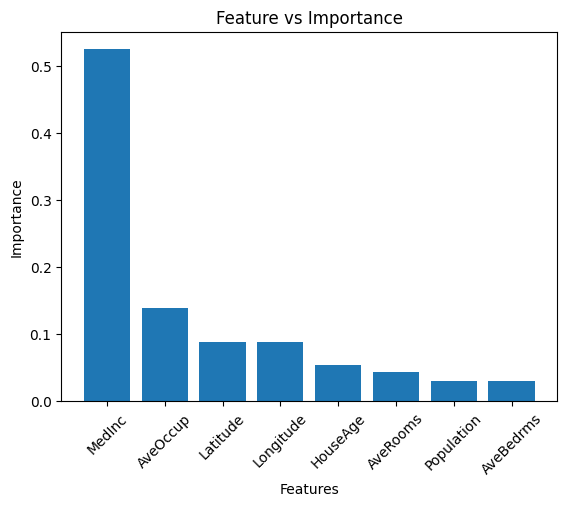

In [55]:
columns = pd.Series(X.columns)
feature_importance = pd.Series(model_4.feature_importances_)
feature_vs_importance = pd.concat((columns,
                                   feature_importance), axis=1
                                  )
feature_vs_importance.columns = ['Feature', 'importance']
feature_vs_importance = feature_vs_importance.sort_values(by='importance',
    ascending=False)
print(feature_vs_importance)

#Visualization

plt.bar(feature_vs_importance['Feature'],
        feature_vs_importance['importance']
)
plt.xlabel('Features')
plt.xticks(rotation=45)
plt.ylabel('Importance')
plt.title('Feature vs Importance')

plt.show()

Median income was the dominant predictor, while geographical coordinates also contributed substantially, highlighting the importance of both socioeconomic conditions and location in predicting median house values.

## 10. Model Comparison

In [56]:
comparison_data = [
    {'Model': 'Linear Regression', 'MAE': mae, 'R2': r2},
    {'Model': 'Decision Tree (Depth 10)', 'MAE': mae_model_3_depth10, 'R2': r2_model_3_depth10},
    {'Model': 'Random Forest', 'MAE': mae_4, 'R2': r2_model_4}
]

model_comparison = pd.DataFrame(comparison_data)
display(model_comparison)

,Model,MAE,R2
0,Linear Regression,0.533200,0.575788
1,Decision Tree (Depth 10),0.433203,0.682948
2,Random Forest,0.327543,0.805123


## 11. Conclusions and Limitations

##Conclusions

The Random Forest performed best among the tested models, achieving the lowest test MAE of approximately 0.328 and the highest test R² of approximately 0.805. Compared with the Linear Regression baseline, it reduced the average absolute prediction error by roughly 0.20 target units, equivalent to about $20,000, while increasing R² by approximately 0.23. However, the gap between training R² (0.974) and test R² (0.805) indicates that the model still shows evidence of overfitting, despite generalising substantially better than the Decision Tree models.

## Limitations

1. Extreme and unusual observations:
The dataset contains extreme observations, such as block groups with unusually high average room counts and very low populations. These cases produced some of the largest prediction errors and may affect summary metrics such as the mean absolute error. The comparison between mean and median errors also showed that the error distribution contains important extremes.

2. Historical dataset:
The California Housing dataset is based on 1990 census data, meaning the learned relationships may not represent the modern housing market. Housing prices and their relationships with income, geography, population patterns and other factors can change substantially over time.

3. Limited model tuning and model selection:
Only a small number of regression algorithms and hyperparameter values were explored. More systematic approaches, such as cross-validation and broader hyperparameter tuning, could potentially improve generalisation and reduce overfitting.

## Future Work

Possible improvements include exploring additional regression algorithms, performing systematic hyperparameter tuning using cross-validation, and evaluating the models on more recent housing datasets.